# Three-Qubit GHZ State Generation

## 1. Objective
The objective of this experiment is to construct a three-qubit **Greenberger-Horne-Zeilinger (GHZ) state**—a maximally entangled tripartite quantum state—using a Hadamard gate and a cascade of chained Controlled-NOT (CNOT) gates. The experiment verifies the tripartite quantum entanglement and correlated measurement statistics through simulation on Qiskit Aer.

---

## 2. Theory

### Initial State
The three-qubit register begins in the standard computational basis ground state:

$$|\psi_0\rangle = |000\rangle = |0\rangle \otimes |0\rangle \otimes |0\rangle$$

### Creating Superposition with the Hadamard Gate
Applying a Hadamard gate ($H$) to the first qubit ($q_0$) creates an equal superposition of $|0\rangle$ and $|1\rangle$:

$$H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$$

The overall 3-qubit product state becomes:

$$|\psi_1\rangle = (H \otimes I \otimes I)|000\rangle = \left(\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right) \otimes |00\rangle = \frac{|000\rangle + |100\rangle}{\sqrt{2}}$$

### Entanglement Propagation via Chained CNOT Gates
To extend entanglement across all three qubits, CNOT operations are chained sequentially:
1. **First CNOT (`qc.cx(0, 1)`)**: Uses $q_0$ as control and $q_1$ as target.
   - If $q_0 = 0$, $q_1$ stays $0 \implies |000\rangle \to |000\rangle$
   - If $q_0 = 1$, $q_1$ flips from $0$ to $1 \implies |100\rangle \to |110\rangle$
   This creates a 2-qubit Bell pair on $q_0, q_1$:
   $$|\psi_2\rangle = \frac{|000\rangle + |110\rangle}{\sqrt{2}}$$

2. **Second CNOT (`qc.cx(1, 2)`)**: Uses $q_1$ as control and $q_2$ as target.
   - If $q_1 = 0$, $q_2$ stays $0 \implies |000\rangle \to |000\rangle$
   - If $q_1 = 1$, $q_2$ flips from $0$ to $1 \implies |110\rangle \to |111\rangle$
   This propagates the entanglement to $q_2$, yielding the **GHZ state**:
   $$|\psi_3\rangle = |\text{GHZ}\rangle = \frac{|000\rangle + |111\rangle}{\sqrt{2}}$$

### Theoretical Measurement Outcomes
In an ideal projective measurement in the computational basis $\{|000\rangle, |001\rangle, \dots, |111\rangle\}$:
- $P(000) = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2} = 50\%$
- $P(111) = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2} = 50\%$
- All other six states (`001`, `010`, `011`, `100`, `101`, `110`) have $0\%$ probability.

Measurement ideally produces only the correlated outcomes `000` and `111` with approximately equal probability. Observing any single qubit immediately determines the state of all three qubits.

## 3. Circuit Explanation & State Evolution
The circuit operates on 3 quantum bits and 3 classical bits:

1. **Hadamard Gate (`qc.h(0)`)**:
   - Acts on qubit $q_0$ to generate the seed superposition $\frac{|0\rangle + |1\rangle}{\sqrt{2}}$.
2. **Chained CNOT Operations (`qc.cx(0, 1)` and `qc.cx(1, 2)`)**:
   - `qc.cx(0, 1)` entangles qubit $q_1$ with qubit $q_0$.
   - `qc.cx(1, 2)` entangles qubit $q_2$ with qubit $q_1$.
   - Together, they propagate the superposition across the entire register, transforming the separable state $|000\rangle$ into the tripartite entangled GHZ state $\frac{|000\rangle + |111\rangle}{\sqrt{2}}$.
3. **Measurement Operations (`qc.measure`)**:
   - Each qubit is measured into its corresponding classical register bit:
     - $q_0 \to c_0$
     - $q_1 \to c_1$
     - $q_2 \to c_2$

---

## 4. Simulation and Measurement
- **Simulation Environment**: Simulated using Qiskit Aer's `AerSimulator()`, modeling an ideal, noise-free quantum backend.
- **Execution Shots**: The circuit is executed for **1024 shots** to collect statistical measurement frequencies.
- **State Counting & Visualization**: The counts for all 8 computational basis states (`'000'` through `'111'`) are extracted and visualized using a Matplotlib bar chart.
- **Programmatic Validation**: A post-measurement assertion checks that the set of observed outcomes is strictly a subset of `{'000', '111'}`.

/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2589/3670948543.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


GHZ State Circuit
     ┌───┐          ┌─┐      
q_0: ┤ H ├──■───────┤M├──────
     └───┘┌─┴─┐     └╥┘┌─┐   
q_1: ─────┤ X ├──■───╫─┤M├───
          └───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     0  1  2 

Measurement Results:
{'000': 501, '111': 523}


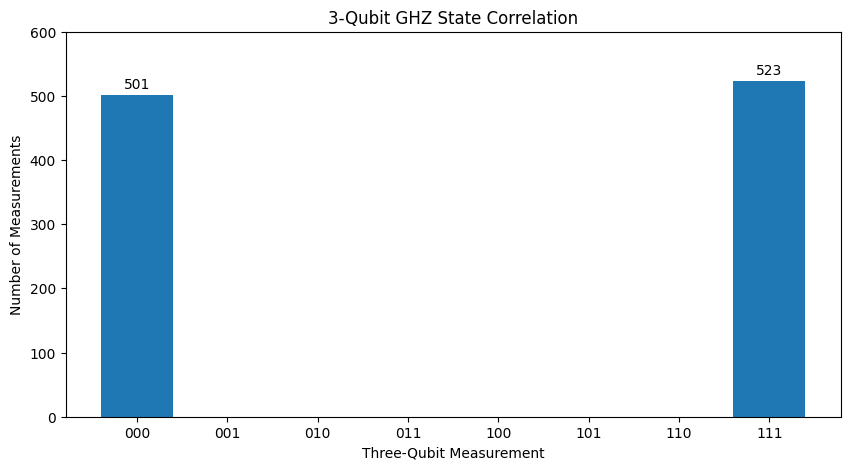


SUCCESS!
Perfect three-way correlation verified.


In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

qc = QuantumCircuit(3, 3)

qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)

qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

print("GHZ State Circuit")
print(qc.draw())

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print("\nMeasurement Results:")
print(counts)

states = [
    '000', '001', '010', '011',
    '100', '101', '110', '111'
]

values = [
    counts.get(state, 0)
    for state in states
]

plt.figure(figsize=(10, 5))

bars = plt.bar(states, values)

plt.xlabel("Three-Qubit Measurement")
plt.ylabel("Number of Measurements")
plt.title("3-Qubit GHZ State Correlation")
plt.ylim(0, 600)

for bar, value in zip(bars, values):
    if value > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 10,
            str(value),
            ha='center'
        )

plt.show()

if set(counts.keys()).issubset({'000', '111'}):
    print("\nSUCCESS!")
    print("Perfect three-way correlation verified.")
else:
    print("\nUnexpected results.")

## 5. Results & Observations

### Observed Measurement Counts
Execution of the circuit on the Aer simulator across 1024 shots produced the following recorded count dictionary:

```python
{'000': 501, '111': 523}
```

### Statistical Analysis
- **Outcome `000`**: Measured **501 times**, corresponding to an empirical frequency of:
  $$\frac{501}{1024} \times 100\% \approx 48.93\%$$
- **Outcome `111`**: Measured **523 times**, corresponding to an empirical frequency of:
  $$\frac{523}{1024} \times 100\% \approx 51.07\%$$
- **Remaining Basis States**: The six other computational basis states (`001`, `010`, `011`, `100`, `101`, `110`) recorded **0 counts** ($0.00\%$), confirming that anti-correlated or partially correlated states do not occur in ideal simulation.
- **Finite-Shot Sampling Variation**: In an infinite-shot limit, the distribution would converge to exactly 50.00% / 50.00% (512 / 512 counts). The observed split (501 vs 523 counts) reflects natural statistical sampling variation for a binomial distribution with $N = 1024$ shots ($\sigma = \sqrt{N \cdot p \cdot (1-p)} = \sqrt{1024 \times 0.5 \times 0.5} = 16$ counts, or $\approx 1.56\%$).
- **Success Verification**: The programmatic verification logic confirmed:
  ```
  SUCCESS!
  Perfect three-way correlation verified.
  ```

## 6. Conclusion
This experiment successfully demonstrates the generation of a three-qubit **GHZ state**:

$$|\text{GHZ}\rangle = \frac{|000\rangle + |111\rangle}{\sqrt{2}}$$

Key findings:
1. **Multi-Qubit Entanglement**: Combining a single-qubit Hadamard gate with chained CNOT gates effectively scales entanglement from a single qubit across multiple qubits.
2. **Tripartite Correlation**: The measurement outcomes exclusively yielded `'000'` ($48.93\%$) and `'111'` ($51.07\%$), with zero occurrences across the remaining six computational basis states.
3. **Non-Local Coherence**: Measuring any single qubit collapses the entire three-qubit register into a uniformly correlated state, illustrating the fundamental properties of maximally entangled multi-qubit systems.